LAB lezione 7: PINNs (Stokes e Schrödinger)

In [ ]:
kk

# **Physics Informed Neural Netwoks** (part 2)



## **Hands on: Stokes' law with constant prediction**

**Goal**: fitting the damping curve for Stokes' law, this time predicting the $\tau$ and $V$ parameters along with the regression.

**Hints**

1.   As source code, take the file from the previous lecture.
2.   $V$ and $\tau$ are unknown variables. Instead of being passed as arguments for the constructor of the NN class, they can be set as random variables inside the constructor itself, according with the requires_grad=True flag:
```
self.tau = torch.rand(1, requires_grad=True)
self.V = torch.rand(1, requires_grad=True)
```
3.   In second place, the values for $\tau$ and $V$ need to be backpropagated in the process of training. To do so, simply append these values when instantiating the parameters of the Network:
```
params = list(self.parameters())
params.append(self.tau)
params.append(self.V)
```
where params are the python variables to be passed to the optimizer.



1 Training Loss: 27.415983200073242
2 Training Loss: 27.023164749145508
3 Training Loss: 26.55504035949707
4 Training Loss: 26.197303771972656
5 Training Loss: 25.888221740722656
6 Training Loss: 25.59624481201172
7 Training Loss: 25.481735229492188
8 Training Loss: 25.164791107177734
9 Training Loss: 25.16373062133789
10 Training Loss: 25.087404251098633
11 Training Loss: 24.882253646850586
12 Training Loss: 24.84134864807129
13 Training Loss: 24.786298751831055
14 Training Loss: 24.722585678100586
15 Training Loss: 24.71354866027832
16 Training Loss: 24.673450469970703
17 Training Loss: 24.680326461791992
18 Training Loss: 24.638750076293945
19 Training Loss: 24.657245635986328
20 Training Loss: 24.641319274902344
21 Training Loss: 24.634517669677734
22 Training Loss: 24.647140502929688
23 Training Loss: 24.67194366455078
24 Training Loss: 24.649585723876953
25 Training Loss: 24.655166625976562
26 Training Loss: 24.651214599609375
27 Training Loss: 24.63589096069336
28 Training Loss:

/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_38446/1867659410.py:142: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  t_test = np.arange(0, 2*net.tau, 1/200).reshape(-1, 1)
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_38446/1867659410.py:143: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v_true = np.array([2 * np.exp(-t / net.tau) + 4 for t in t_test])


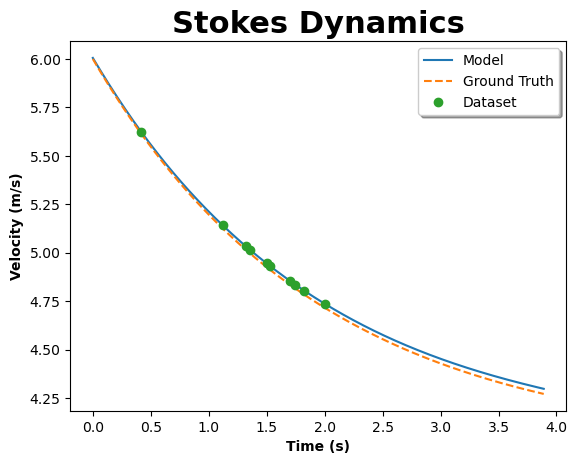

In [ ]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt


## For further inspiration, take a look at
## https://github.com/nanditadoloi/PINN/blob/main/solve_PDE_NN.ipynb


###########
## MODEL ##
###########
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.hidden_layer1 = nn.Linear(1,5)
        self.hidden_layer2 = nn.Linear(5,5)
        self.hidden_layer3 = nn.Linear(5,5)
        self.hidden_layer4 = nn.Linear(5,5)
        self.hidden_layer5 = nn.Linear(5,5)
        self.output_layer = nn.Linear(5,1)

        ## Diff. Eq. Params ##
        self.tau = torch.rand(1, requires_grad=True)
        self.V = torch.rand(1, requires_grad=True)
        params = list(self.parameters())
        params.append(self.tau)
        params.append(self.V)

        ## TODO: define the optimizer
        self.optimizer = torch.optim.Adam(params, lr=0.001)

        ## TODO: define the loss function
        self.criterion = torch.nn.MSELoss()


    def forward(self, t):
        inputs = torch.cat([t], axis=1)
        layer1_out = torch.sigmoid(self.hidden_layer1(inputs))
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
        layer3_out = torch.sigmoid(self.hidden_layer3(layer2_out))
        layer4_out = torch.sigmoid(self.hidden_layer4(layer3_out))
        layer5_out = torch.sigmoid(self.hidden_layer5(layer4_out))
        ## For regression, no activation is used in output layer ##
        output = self.output_layer(layer5_out)
        return output

    def diff_eq(self, t):
        """
        This method returns an implicit function which set = 0 gives the differential equation
        :param t: the times used to estimate the value of the function F(t)
        :return: the implicit function F(t)
        """
        ## TODO: predict the velocities
        #vel[0] = v0
        #vel = A*np.exp(-t/tau_) + C
        vel = self.forward(t)
        ## TODO: derive the velocities with respect to t (first order derivative dv/dt)
        #vel_der = -A/tau_ * np.exp(-t/tau_)
        vel_der = torch.autograd.grad(vel.sum(), t, create_graph=True)[0]
        ## TODO: return the implicit function for the differential equation
        
        return vel_der + vel / self.tau - self.V
    


    def train_step(self, diff_eq_times, dataset_times, dataset_vel):
        """
        This method train the NN model using the data loss and the differential equation loss
        :param diff_eq_times: tensor of times used to estimate the differential equation
        :param dataset_times: tensor of times used to estimate the velocities using the NN
        :param dataset_vel: tensor of "labels" used to estimate the data loss
        :return: the total loss: loss_total = loss_data + loss_diff_eq
        """
        #reset gradients
        self.optimizer.zero_grad()

        # TODO: estimate the data loss (take inspiration from the parabola.py or the Ising files)
        # Passing the node features and the connection info
        prediction = self.forward(dataset_times)
        # Calculating the loss and gradients
        loss_data = self.criterion(prediction, dataset_vel)
        # Here we estimate the differential equation loss
        f_out = self.diff_eq(diff_eq_times)  # output of f(x,t)
        zeros_diff_eq = torch.zeros(size=(500, 1), requires_grad=False, dtype=torch.float32)
        loss_diff_eq = self.criterion(f_out, zeros_diff_eq)

        # TODO: sum the two losses (loss_total)
        loss_total = loss_data + loss_diff_eq
        # TODO: compute the total backpropagation
        loss_total.backward(retain_graph = True)
        self.optimizer.step()

        return loss_total.item()


##############
## TRAINING ##
##############
def main():
    ## Data upload ##
    dataset_ = np.load("STOKES_dataset.npz")
    #dataset_ = np.load("STOKES_dataset_noisy.npz")
    t_dataset, v_dataset = dataset_["times"], dataset_["velocities"]


    ## Dataset in tensor format ##
    times_data = torch.tensor(t_dataset, requires_grad=True, dtype=torch.float32)
    velocities = torch.tensor(v_dataset, requires_grad=True, dtype=torch.float32)

    ## TODO: Instantiate the model
    net = PINN()
    V_ = net.V
    tau_ = net.tau
    tau_true = 2.0
    times_min, times_max = 0.0, 4.0
    ## TODO: Train the model and define number of epochs and batch size
    n_epochs = 30000
    batch_size = 500
    for epoch in range(n_epochs):
        ## Differential Equation data ##
        times_eq = (times_min - times_max) * torch.rand(size=(batch_size, 1),requires_grad=True,
                                                        dtype=torch.float32) + times_max

        loss = net.train_step(diff_eq_times=times_eq, dataset_times=times_data, dataset_vel=velocities)

        print(epoch+1, "Training Loss:", loss)


    ############## TEST ##############
    ## Generate a sequence of times ##
    ## Plot the model predictions   ##
    ## Plot the true dynamic curve  ##
    ## Plot the dataset of (t,v)    ##
    ##################################
    print(44 * '-')
    print('\nTesting ...')
    ## Data to plot ##
    with torch.autograd.no_grad():
        t_test = np.arange(0, 2*net.tau, 1/200).reshape(-1, 1)
        v_true = np.array([2 * np.exp(-t / net.tau) + 4 for t in t_test])
        ## TODO: predict the velocities from t_test in order to plot them
        ## use .detach().numpy() method to convert torch.tensor to numpy
        t_test = torch.tensor(t_test, dtype=torch.float32)
        v_test = net(t_test)
        v_test = v_test.detach().numpy()


    ## Plotting ##
    fig, ax = plt.subplots()
    ax.plot(t_test, v_test, label="Model")
    ax.plot(t_test, v_true, '--', label="Ground Truth")
    ax.plot(t_dataset, v_dataset, 'o', label="Dataset")

    ax.legend(loc='upper right', shadow=True)
    ax.set_xlabel('Time (s)', weight='bold')
    ax.set_ylabel('Velocity (m/s)', weight='bold')
    ax.set_title('Stokes Dynamics', fontsize=22, weight='bold')
    plt.show()


if __name__=="__main__":
    main()


## **Schrödinger equation by PINN**

## **Hands on: monodimensional harmonic oscillator by PINN**

**Goal**: in the experiment we would like to deal with, the length of the system will be given by $6a_0$. Within this range, knowing the energy of the system, we would like to:

1.   Integrate the differential equation in order to shape the wavefunction $\psi(x)$
2.   Achieve the value for the $\omega$ pulsation: once such value is returned, get the $n$-th energy level by the formula $E_n = \omega (n + \frac{1}{2})$, as in a.u. $\hbar=1$. Set the energy of the ground state system to be $E_0=2.75$ a.u.



**Hints**


1.   Schrödinger equation is a second-order differential equation: in order to derive twice the Neural Network, it is possible to implement the following transformation:
```
psi_x = torch.autograd.grad(psi.sum(), x, create_graph=True)[0]
psi_xx = torch.autograd.grad(psi_x.sum(), x, create_graph=True)[0]
```
2.   As the range for the experiment to take place is $[-6a_0; 6a_0]$, in a.u. you may integrate the differential equation in the $[-6;6]$ domain.
3.   As for the NN architecture, try to implement 3 or 4 layers. The training will be hard: set at least 10.000 epochs.
4.   You may find out your dataset in SCHRODINGER_dataset.npz from the current folder.



1 Training Loss: 0.35891851782798767
2 Training Loss: 0.3405976891517639
3 Training Loss: 0.3220314681529999
4 Training Loss: 0.3043479025363922
5 Training Loss: 0.2879520356655121
6 Training Loss: 0.27171608805656433
7 Training Loss: 0.25629034638404846
8 Training Loss: 0.24194100499153137
9 Training Loss: 0.22795456647872925
10 Training Loss: 0.21495762467384338
11 Training Loss: 0.20271876454353333
12 Training Loss: 0.1913537234067917
13 Training Loss: 0.18055501580238342
14 Training Loss: 0.17006608843803406
15 Training Loss: 0.1611141711473465
16 Training Loss: 0.15217655897140503
17 Training Loss: 0.14412426948547363
18 Training Loss: 0.13680791854858398
19 Training Loss: 0.1298786848783493
20 Training Loss: 0.12366025894880295
21 Training Loss: 0.11796766519546509
22 Training Loss: 0.11279928684234619
23 Training Loss: 0.10826514661312103
24 Training Loss: 0.10426120460033417
25 Training Loss: 0.10049089789390564
26 Training Loss: 0.09726079553365707
27 Training Loss: 0.09434767

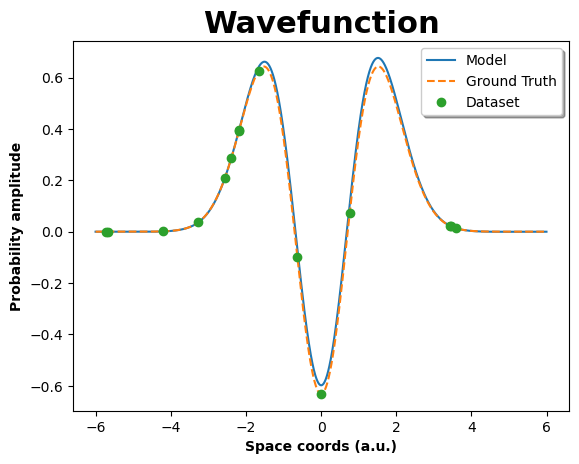

In [15]:
import torch
import torch.nn as nn
from scipy.special import hermite

import numpy as np
import matplotlib.pyplot as plt


## For further inspiration, take a look at
## https://github.com/nanditadoloi/PINN/blob/main/solve_PDE_NN.ipynb


###########
## MODEL ##
###########
class PINN(nn.Module):
    def __init__(self, energy):
        super(PINN, self).__init__()
        self.hidden_layer1 = nn.Linear(1,40)
        self.hidden_layer2 = nn.Linear(40,20)
        self.hidden_layer3 = nn.Linear(20, 10)
        self.hidden_layer4 = nn.Linear(10, 5)
        self.output_layer = nn.Linear(5,1)

        ## Diff. Eq. Params ##
        self.omega = torch.rand(1, requires_grad=True)
        self.E = energy

        params = list(self.parameters())
        params.append(self.omega)

        ## TODO: define the optimizer
        self.optimizer = torch.optim.Adam(params, lr=0.001)

        ## TODO: define the loss function
        self.criterion = torch.nn.MSELoss()

    def forward(self, x):
        inputs = torch.cat([x], axis=1)
        layer1_out = torch.sigmoid(self.hidden_layer1(inputs))
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
        layer3_out = torch.sigmoid(self.hidden_layer3(layer2_out))
        layer4_out = torch.sigmoid(self.hidden_layer4(layer3_out))
        ## For regression, no activation is used in output layer ##
        output = self.output_layer(layer4_out)
        return output

    def diff_eq(self, x):
        """
        This method returns an implicit function which set = 0 gives the differential equation
        :param t: the times used to estimate the value of the function f(t)
        :return: the implicit function f(t)
        """
        ## TODO: predict the value of psi
        psi = self.forward(x)
        ## TODO: derive first and second order of psi
        psi_x = torch.autograd.grad(psi.sum(),x,create_graph=True)[0]
        psi_xx = torch.autograd.grad(psi_x.sum(),x,create_graph=True)[0]
        ## TODO: return the implicit function for the differential equation

        return -0.5 * psi_xx + 0.5 * (self.omega * x)**2 * psi - self.E * psi 

    def train_step(self, diff_eq_x, dataset_x, amplitudes):
        """
        This method train the NN model using the data loss and the differential equation loss
        :param diff_eq_x: tensor of positions used to estimate the differential equation
        :param dataset_x: tensor of positions used to estimate the velocities using the NN
        :param amplitudes: tensor of "labels" used to estimate the data loss
        :return: the total loss: loss_total = loss_data + loss_diff_eq
        """
        self.optimizer.zero_grad()

        # TODO: estimate the data loss (take inspiration from the parabola.py or the Ising files)
        prediction = self.forward(dataset_x)
        loss_data = self.criterion(prediction, amplitudes)
        # Here we estimate the differential equation loss
        f_out = self.diff_eq(diff_eq_x) # output of f(x,t)
        zeros_diff_eq = torch.zeros(size=(500, 1), requires_grad=False, dtype=torch.float32)
        loss_diff_eq = self.criterion(f_out, zeros_diff_eq)

        # TODO: sum the two losses (loss_total)
        loss_total = loss_data + loss_diff_eq
        ## TODO: compute the total backpropagation
        loss_total.backward()
        self.optimizer.step()

        return loss_total.item()


def wavefunc(x, n, omega):
    H = hermite(n)
    return (2 / np.pi)**(1/4) * np.exp(-omega / 2 * x ** 2) / np.sqrt(2**n * np.prod(n)) * H(x)



##############
## TRAINING ##
##############
def main():
    ## Parameters ##
    energy = 2.75
    x_min, x_max = -6, 6

    dataset_ = np.load("SCHRODINGER_dataset.npz")
    x_data, psi_dataset = dataset_["x_data"], dataset_["psi_data"]

    x_data = torch.tensor(x_data, requires_grad=True, dtype=torch.float32)
    psi_dataset = torch.tensor(psi_dataset, requires_grad=True, dtype=torch.float32)

    ## TODO: Instantiate the model
    net = PINN(energy)

    ## TODO: Train the model, define number of epochs
    n_epochs = 30000
    batch_size = 500
    for epoch in range(n_epochs):

        ## Differential Equation data ##
        x_eq = (x_min - x_max) * torch.rand(size=(batch_size, 1), requires_grad=True, dtype=torch.float32) + x_max

        loss = net.train_step(diff_eq_x=x_eq, dataset_x=x_data, amplitudes=psi_dataset)

        print(epoch+1, "Training Loss:", loss)


    ############## TEST ##############
    ## Generate a sequence of times ##
    ## Plot the model predictions   ##
    ## Plot the true dynamic curve  ##
    ## Plot the dataset of (t,v)    ##
    ##################################
    with torch.autograd.no_grad():

        #print("Learned omega: {}".format(net.omega))
        n_pred = round(energy/net.omega.item() - .5)
        omega = net.omega.item()
        print("Learned omega: {}".format(omega))
        print("Energy level: {}".format(n_pred))

        ## Data to plot ##
        x_test = np.arange(x_min, x_max, 1/200).reshape((x_max-x_min)*200, 1)
        psi_true = np.array([wavefunc(x, n_pred, omega) for x in x_test])
        ## TODO: predict the velocities from t_test in order to plot them
        x_test = torch.tensor(x_test, dtype=torch.float32)
        psi_test = net(x_test)
        psi_test = psi_test.detach().numpy()


    ## Plotting ##
    fig, ax = plt.subplots()
    ax.plot(x_test.detach().numpy(), psi_test, label="Model")
    ax.plot(x_test.detach().numpy(), psi_true, '--', label="Ground Truth")
    ax.plot(x_data.detach().numpy(), psi_dataset.detach().numpy(), 'o', label="Dataset")

    ax.legend(loc='upper right', shadow=True)
    ax.set_xlabel('Space coords (a.u.)', weight='bold')
    ax.set_ylabel('Probability amplitude', weight='bold')
    ax.set_title('Wavefunction', fontsize=22, weight='bold')
    plt.show()


if __name__=="__main__":
    main()
